In [26]:
from idun_guardian_sdk import GuardianClient, FileTypes
import pandas as pd
import scipy.signal as signal
import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import welch
from scipy.integrate import trapezoid
import seaborn as sns

In [27]:
# Parameters
my_api_token = "idun_MWSQ4pkewAGNz8wwYzw_NsweXihLC8tIcFzah8vqqys4Nc-ALzjfTwl2"
my_recording_id = "1776148604104"

# Start times for each segment of the recording (in seconds)
Rest1_start = 0
Game1_start = 120
Rest2_start = 480
Game2_start = 600
Rest3_start = 780
end_time = 900

# ---------------------------------------------------
# SEGMENTS (seconds)
# ---------------------------------------------------

segments = {
    "rest1": (Rest1_start, Game1_start),
    "game1": (Game1_start, Rest2_start),
    "rest2": (Rest2_start, Game2_start),
    "game2": (Game2_start, Rest3_start),
    "rest3": (Rest3_start, end_time),
}

# ensure combined label exists
rests = ["rest1", "rest2", "rest3"]
games = ["game1", "game2"]

# ---------------------------------------------------
# MANUAL SEGMENT COLORS
# ---------------------------------------------------
segment_colors = {
    "rest1": "cyan",
    "game1": "magenta",
    "rest2": "cyan",
    "game2": "magenta",
    "rest3": "cyan"
}
individual_colors = {
    "rest1": "blue",
    "game1": "red",
    "rest2": "cyan",
    "game2": "magenta",
    "rest3": "green"
}
# ---------------------------------------------------
# Bands and their frequency ranges (Hz)
# ---------------------------------------------------
bands = {
    "delta": (0.5, 4),
    "theta": (4, 8),
    "alpha": (8, 12),
    "beta": (12, 30),
    "gamma": (30, 40)
}
bandslist = ["delta", "theta", "alpha", "sigma", "beta", "gamma"]
# ---------------------------------------------------
# VISUALIZATION ---------------
colors = {
    "delta": "blue",
    "theta": "red",
    "alpha": "green",
    "sigma": "purple",
    "beta": "orange",
    "gamma": "brown"
}




[INFO] 2026-04-20 19:02:54,605: [API]: File saved: 'eeg_1776148604104.csv'
[INFO] 2026-04-20 19:02:54,605: [API]: File saved: 'eeg_1776148604104.csv'
[INFO] 2026-04-20 19:02:54,605: [API]: File saved: 'eeg_1776148604104.csv'


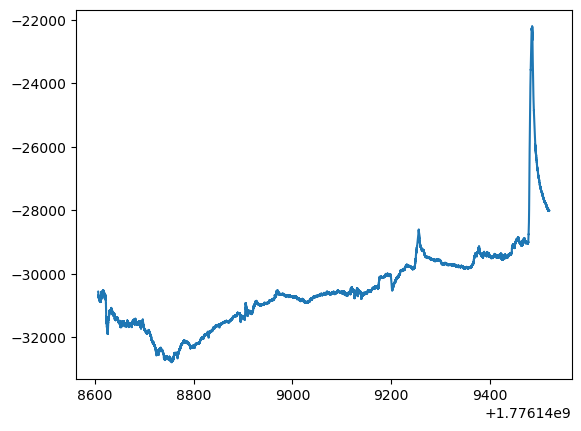

In [28]:
filename = "eeg_" + my_recording_id + ".csv"

if __name__ == "__main__":
    client = GuardianClient(api_token=my_api_token)
    client.download_file(recording_id=my_recording_id, file_type=FileTypes.EEG)

x = pd.read_csv(filename)
plt.plot(x["timestamp"], x["ch1"])

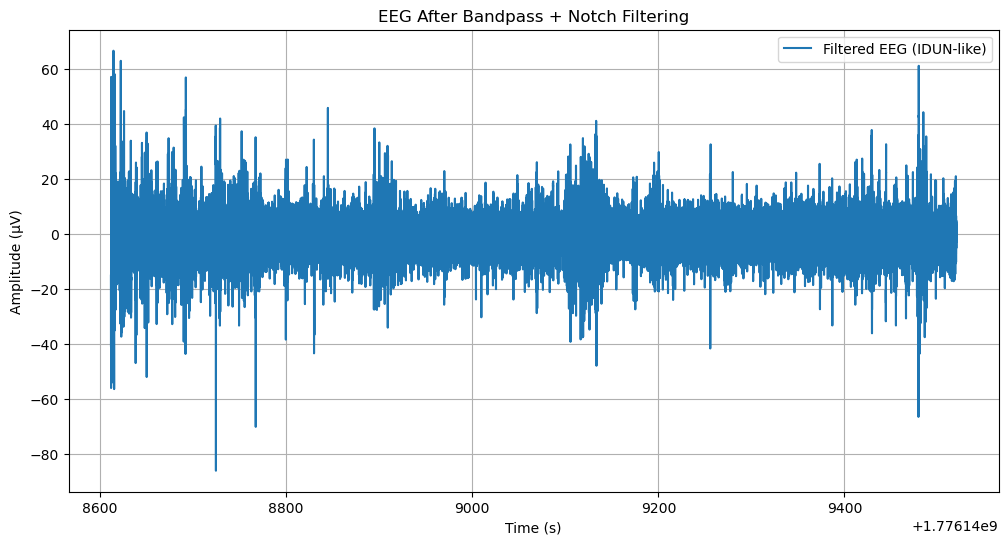

In [29]:
# fs = sampling rate (e.g. 250)
fs = 250
window_size = 5 * fs  # 5-second windows
# ---------------------------------------------------
# 1. BANDPASS (1–40 Hz)
# ---------------------------------------------------
sos_bp = signal.butter(
    N=4,
    Wn=[1, 40],
    btype="bandpass",
    fs=fs,
    output="sos"
)

x_bp = signal.sosfiltfilt(sos_bp, x['ch1'])

# ---------------------------------------------------
# 2. NOTCH (50 Hz) — use filtfilt (recommended)
# ---------------------------------------------------
b_notch, a_notch = signal.iirnotch(50, Q=30, fs=fs)
x_filt = signal.filtfilt(b_notch, a_notch, x_bp)

# ---------------------------------------------------
# 3. Remove DC offset
# ---------------------------------------------------
x_filt = x_filt - np.mean(x_filt)

# remove first 5 seconds (calibration period)
cutoff_idx = 5 * fs
x_filt = x_filt[cutoff_idx:]
x = x.iloc[cutoff_idx:]

# ---------------------------------------------------
# 4. Plot
# ---------------------------------------------------
plt.figure(figsize=(12, 6))
plt.plot(x['timestamp'], x_filt, label='Filtered EEG (IDUN-like)')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude (µV)')
plt.title('EEG After Bandpass + Notch Filtering')
plt.grid()
plt.legend()
plt.show()

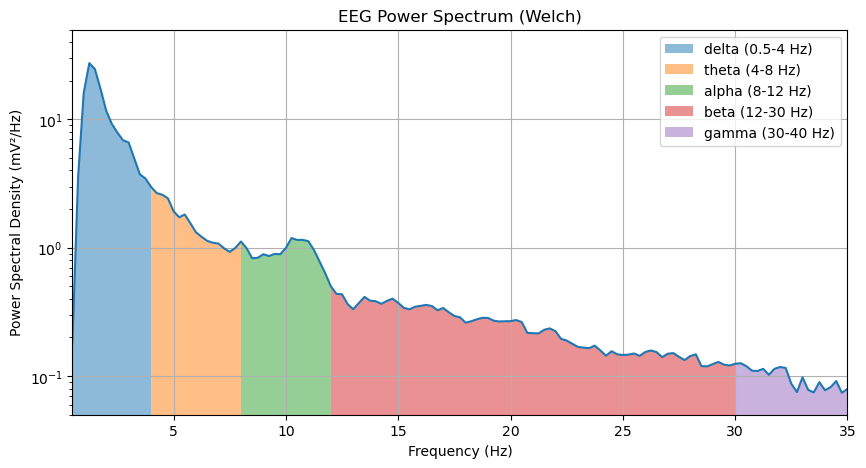

In [30]:
# pick a segment (important!)
segment = x_filt  # first 10 seconds for example

# PSD
freqs, psd = welch(
    segment,
    fs=fs,
    nperseg=fs * 4,
    noverlap=fs * 2
)

# ---------------------------------------------------
# PLOT POWER SPECTRUM
# ---------------------------------------------------
plt.figure(figsize=(10, 5))

plt.semilogy(freqs, psd)  # log scale is standard for EEG

plt.xlabel("Frequency (Hz)")
plt.ylabel("Power Spectral Density (mV²/Hz)")
plt.title("EEG Power Spectrum (Welch)")
plt.grid(True)

plt.ylim([0.05,50])  # adjust as needed for visibility
plt.xlim([0.5, 35])  # focus on 0-50 Hz

# fill area under curve for each frequency band

for band, (f_low, f_high) in bands.items():
    idx_band = np.logical_and(freqs >= f_low, freqs <= f_high)
    plt.fill_between(freqs[idx_band], psd[idx_band], alpha=0.5, label=f"{band} ({f_low}-{f_high} Hz)")
plt.legend()


plt.show()

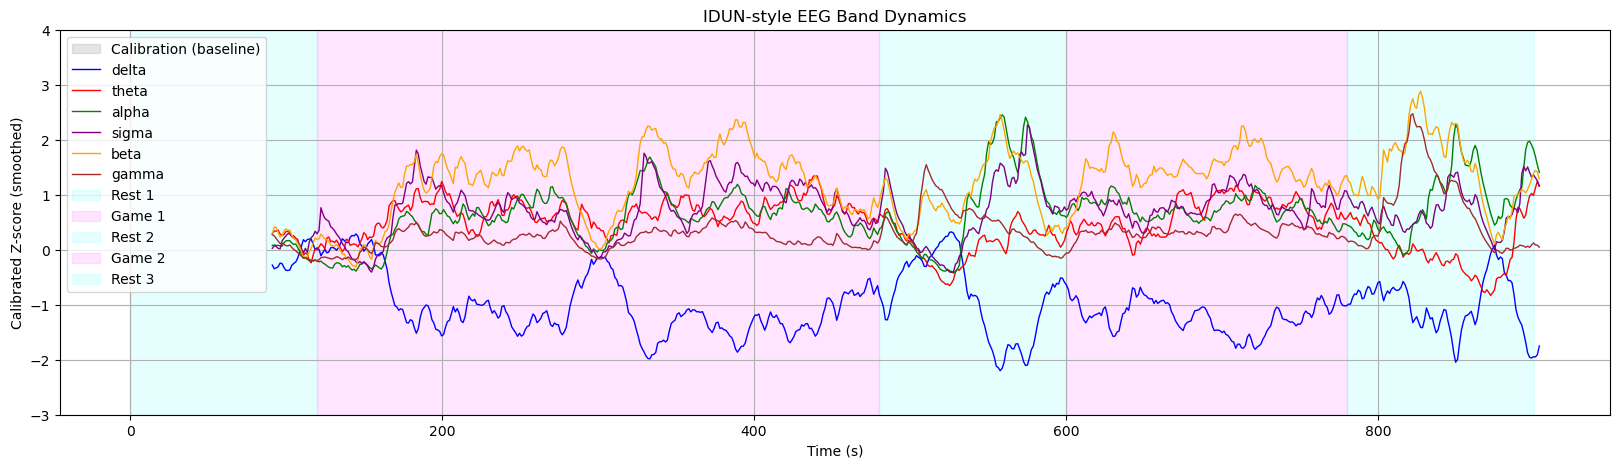

In [31]:
# ---------------------------------------------------
# ASSUMPTIONS
# ---------------------------------------------------
# x_filt = your filtered EEG signal (1D numpy array)


# ---------------------------------------------------
# Band power function
# ---------------------------------------------------
def band_power(freqs, psd, low, high):
    mask = (freqs >= low) & (freqs < high)
    if np.sum(mask) == 0:
        return 0.0
    return trapezoid(psd[mask], freqs[mask])

# ---------------------------------------------------
# Parameters (IDUN-like settings)
# ---------------------------------------------------
window_size = 5 * fs
step_size = int(window_size * 0.25)  # 75% overlap


# ---------------------------------------------------
# FEATURE EXTRACTION (PSD-based)
# ---------------------------------------------------
features = []

for i in range(0, len(x_filt) - window_size, step_size):
    segment = x_filt[i:i + window_size]

    freqs, psd = welch(
        segment,
        fs=fs,
        nperseg=fs * 4,
        noverlap=fs * 2,
    )

    eps = 1e-8
    features.append([
        band_power(freqs, psd, 0.5, 4) + eps,   # delta
        band_power(freqs, psd, 4, 8) + eps,     # theta
        band_power(freqs, psd, 8, 12) + eps,    # alpha
        band_power(freqs, psd, 12, 15) + eps,   # sigma
        band_power(freqs, psd, 15, 30) + eps,   # beta
        band_power(freqs, psd, 30, 35) + eps,   # gamma
    ])

# ---------------------------------------------------
# DATAFRAME
# ---------------------------------------------------
df = pd.DataFrame(features, columns=bandslist)

df["time_sec"] = np.arange(len(df)) * (step_size / fs)
df["time_hr"] = df["time_sec"] / 3600

# ---------------------------------------------------
# RELATIVE POWER
# ---------------------------------------------------
df["total"] = df[bandslist].sum(axis=1)

for b in bandslist:
    df[f"{b}_rel"] = df[b] / df["total"]


# ---------------------------------------------------
# CALIBRATION (IDUN-style baseline)
# ---------------------------------------------------
calibration_time = 90
cutoff_idx = int(calibration_time / (step_size / fs))

cal_df = df.iloc[:cutoff_idx]

baseline_mean = cal_df[[f"{b}_rel" for b in bandslist]].mean()
baseline_std = cal_df[[f"{b}_rel" for b in bandslist]].std().replace(0, 1e-8)

# ---------------------------------------------------
# Z-SCORE + SMOOTHING (IDUN-like output layer)
# ---------------------------------------------------
for b in bandslist:
    rel = f"{b}_rel"

    df[f"{b}_z"] = (df[rel] - baseline_mean[rel]) / baseline_std[rel]

    # exponential smoothing (wearable EEG style)
    df[f"{b}_smooth"] = df[f"{b}_z"].ewm(span=25).mean()


plt.figure(figsize=(20, 5))

# Calibration block (grey)
plt.axvspan(
    0,
    df["time_hr"].iloc[cutoff_idx], # or time_sec for seconds
    color="grey",
    alpha=0.2,
    label="Calibration (baseline)"
)

# Hide calibration data from curves (IDUN-style UX)
df_plot = df.copy()
for b in bandslist:
    df_plot.loc[:cutoff_idx, f"{b}_smooth"] = np.nan

# Plot post-calibration signals
for b in bandslist:  # IDUN focuses on these 3 bands
    plt.plot(
        df["time_sec"], # or time_sec for seconds
        df_plot[f"{b}_smooth"],
        label=b,
        color=colors[b],
        linewidth=1,
        alpha=1
    )

# plot areas for game and rest periods

# rest 1: 0-2 min
plt.axvspan(Rest1_start, Game1_start, color="cyan", alpha=0.1, label="Rest 1")
# game 1: 2-8 min
plt.axvspan(Game1_start, Rest2_start, color="magenta", alpha=0.1, label="Game 1")
# rest 2: 8-10 min
plt.axvspan(Rest2_start, Game2_start, color="cyan", alpha=0.1, label="Rest 2")
# game 2: 10-13 min
plt.axvspan(Game2_start, Rest3_start, color="magenta", alpha=0.1, label="Game 2")
# rest 3: 13-15 min
plt.axvspan(Rest3_start, end_time, color="cyan", alpha=0.1, label="Rest 3")
plt.xlabel("Time (s)")
plt.ylabel("Calibrated Z-score (smoothed)")
plt.title("IDUN-style EEG Band Dynamics")
plt.legend()
plt.grid()
plt.ylim(-3, 4)
plt.show()

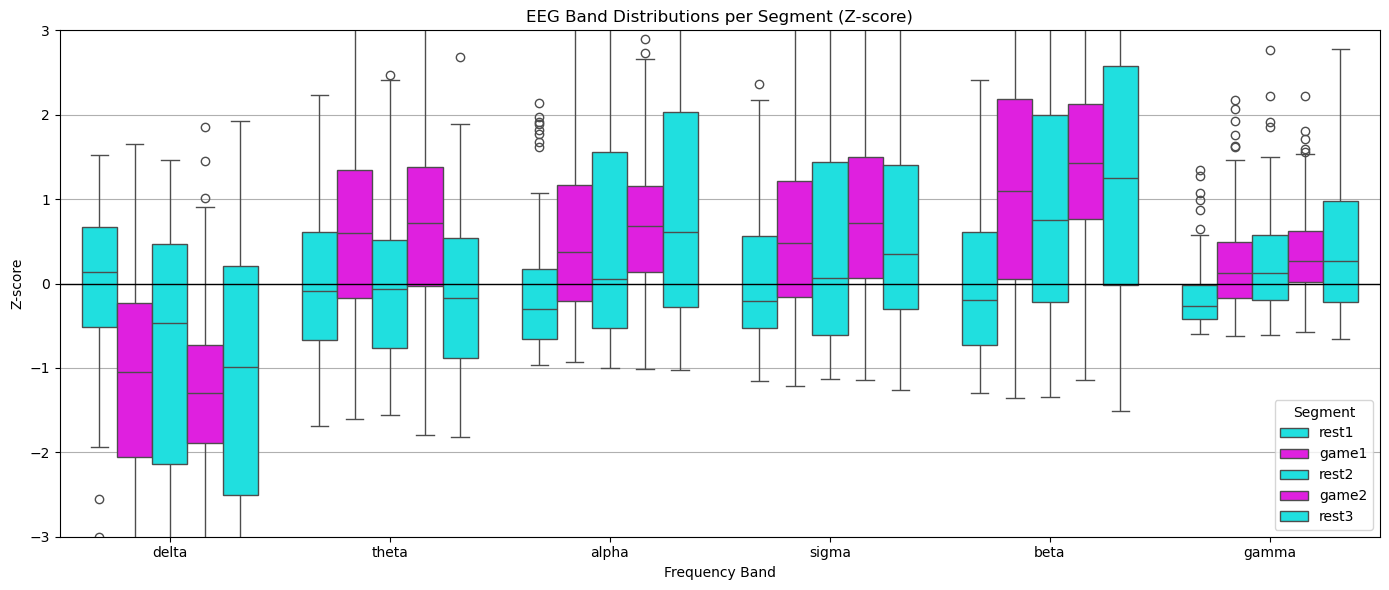

C:\Users\ruegg\AppData\Local\Temp\ipykernel_25224\3564523091.py:70: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
C:\Users\ruegg\AppData\Local\Temp\ipykernel_25224\3564523091.py:70: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
C:\Users\ruegg\AppData\Local\Temp\ipykernel_25224\3564523091.py:70: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
C:\Users\ruegg\AppData\Local\Temp\ipykernel_25224\3564523091.py:70: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` varia

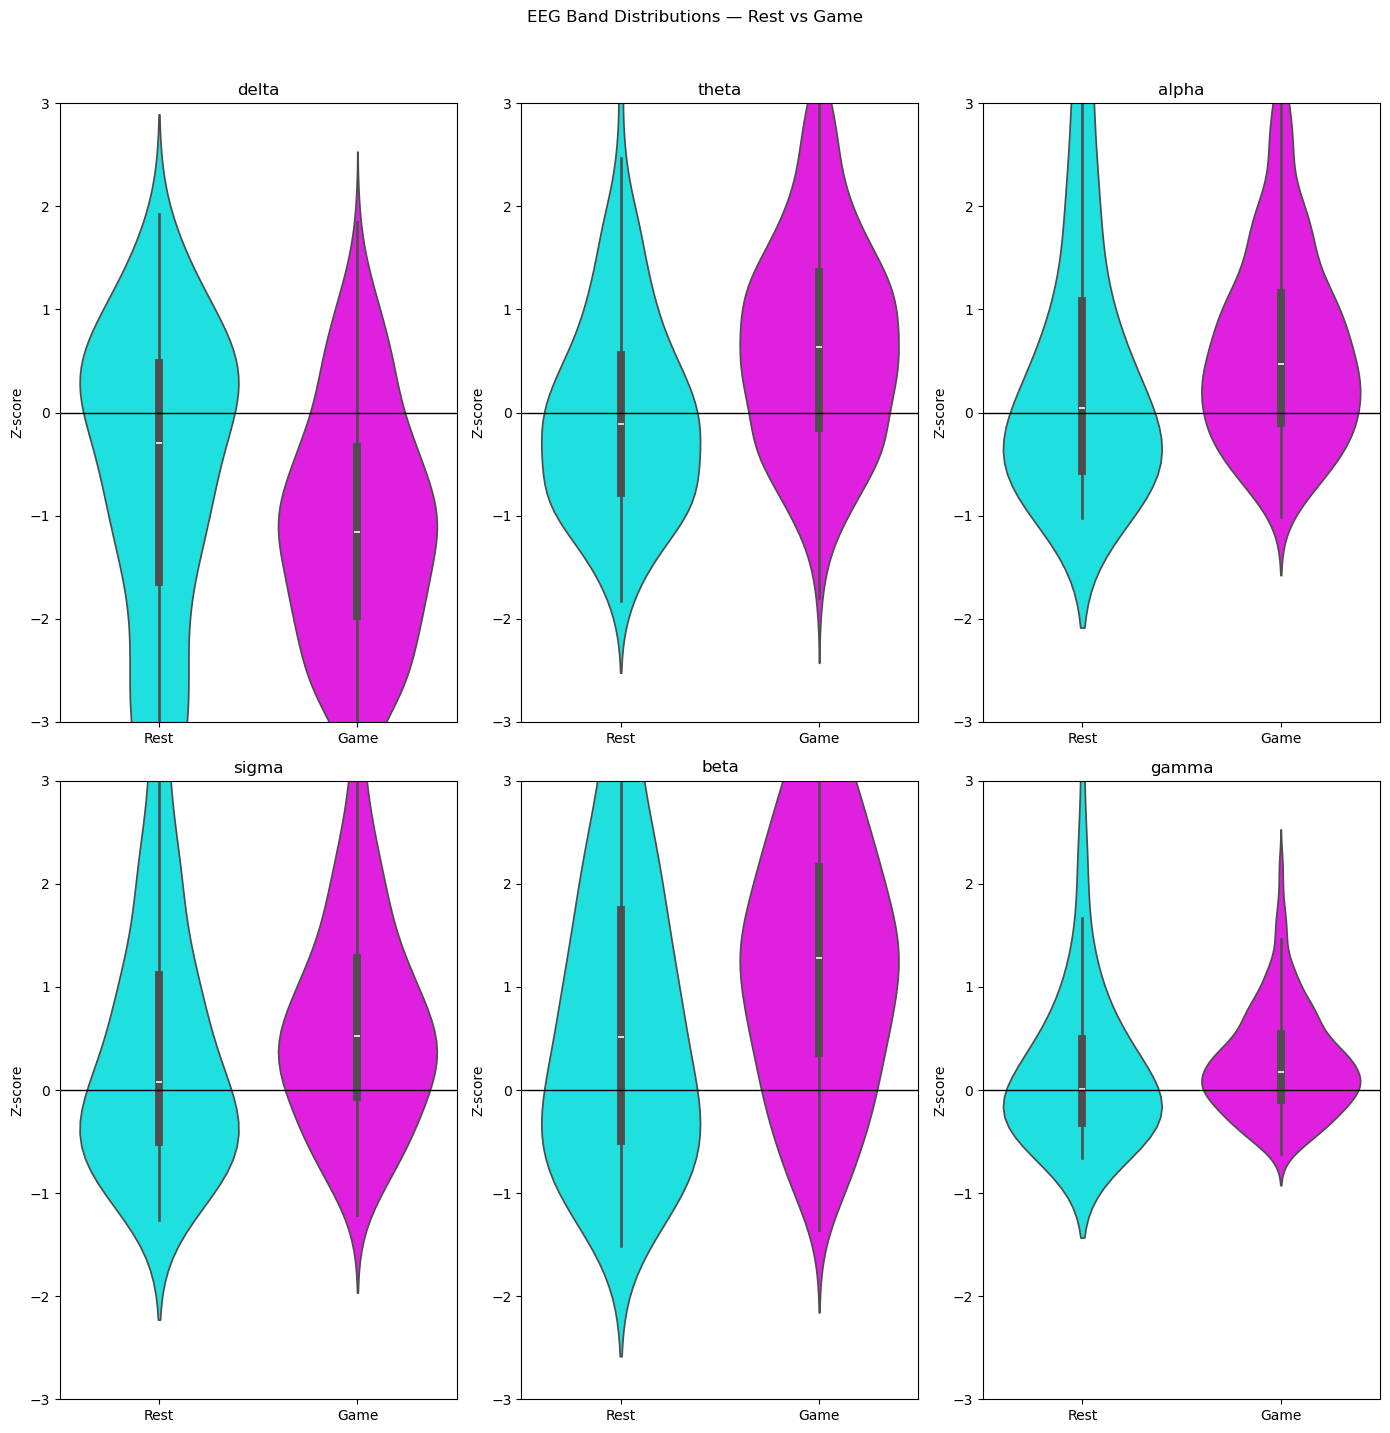

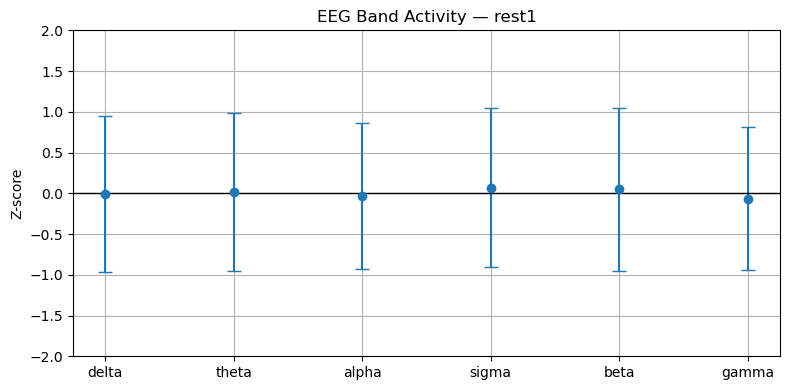

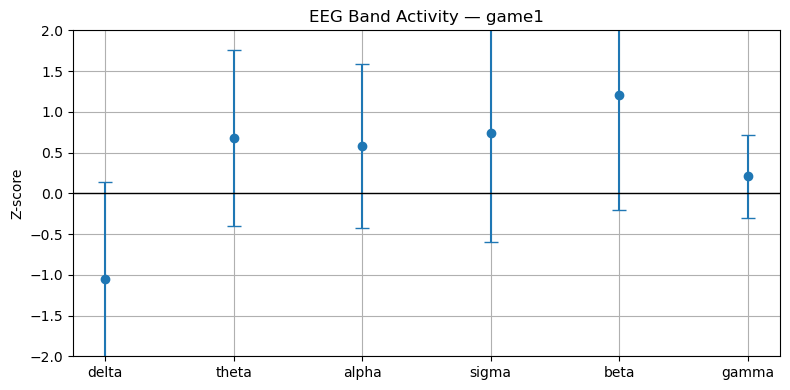

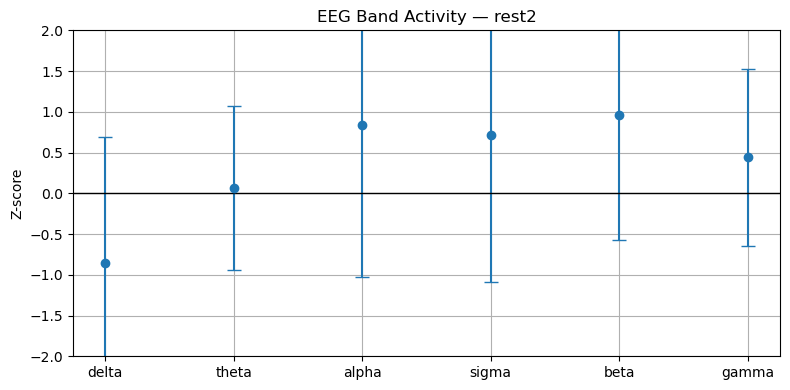

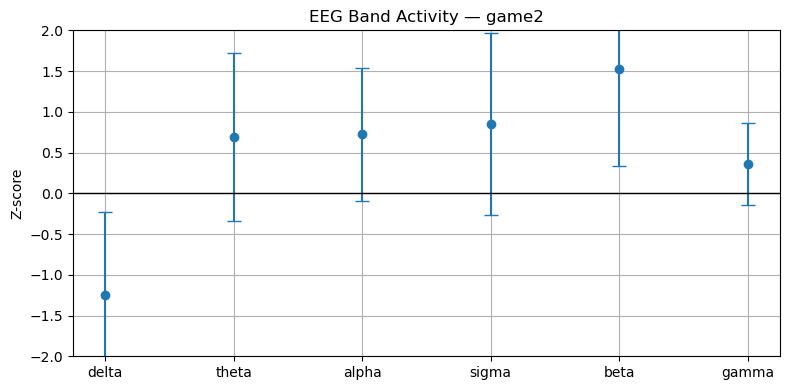

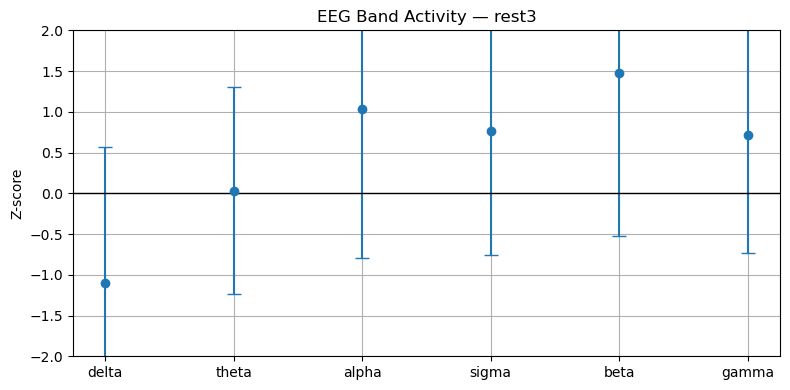

rest1:
  delta: -0.01 ± 0.96
  theta: 0.02 ± 0.97
  alpha: -0.03 ± 0.89
  sigma: 0.07 ± 0.98
  beta: 0.05 ± 1.00
  gamma: -0.07 ± 0.87
game1:
  delta: -1.05 ± 1.19
  theta: 0.68 ± 1.08
  alpha: 0.58 ± 1.01
  sigma: 0.74 ± 1.33
  beta: 1.21 ± 1.41
  gamma: 0.21 ± 0.51
rest2:
  delta: -0.85 ± 1.54
  theta: 0.06 ± 1.01
  alpha: 0.84 ± 1.87
  sigma: 0.71 ± 1.80
  beta: 0.97 ± 1.54
  gamma: 0.44 ± 1.09
game2:
  delta: -1.25 ± 1.03
  theta: 0.69 ± 1.03
  alpha: 0.73 ± 0.82
  sigma: 0.86 ± 1.12
  beta: 1.53 ± 1.19
  gamma: 0.36 ± 0.50
rest3:
  delta: -1.11 ± 1.68
  theta: 0.03 ± 1.27
  alpha: 1.03 ± 1.82
  sigma: 0.76 ± 1.52
  beta: 1.47 ± 1.99
  gamma: 0.72 ± 1.45


In [32]:
z_bands = [f"{b}_z" for b in bandslist]

# ---------------------------------------------------
# ASSIGN SEGMENT LABELS
# ---------------------------------------------------
df["segment"] = "other"

for name, (start, end) in segments.items():
    mask = (df["time_sec"] >= start) & (df["time_sec"] < end)
    df.loc[mask, "segment"] = name

# ---------------------------------------------------
# MELT DATA (required for seaborn boxplot)
# ---------------------------------------------------
plot_df = df[df["segment"] != "other"].copy()

melted = plot_df.melt(
    id_vars=["segment"],
    value_vars=z_bands,
    var_name="band",
    value_name="zscore"
)

melted["band"] = melted["band"].str.replace("_z", "")

# ---------------------------------------------------
# BOX + WHISKER PLOT
# ---------------------------------------------------
plt.figure(figsize=(14, 6))

sns.boxplot(
    data=melted,
    x="band",
    y="zscore",
    hue="segment",
    palette=segment_colors
)

plt.axhline(0, color="black", linewidth=1)

plt.title("EEG Band Distributions per Segment (Z-score)")
plt.ylabel("Z-score")
plt.xlabel("Frequency Band")

plt.legend(title="Segment")
plt.grid(axis="y")
plt.ylim(-3, 3)
plt.tight_layout()

plt.show()



melted["segment_combined"] = melted["segment"].apply(
    lambda x: "Rest" if x in rests else ("Game" if x in games else "Other")
)

plot_df = melted[melted["segment_combined"] != "Other"]

# ---------------------------------------------------
# FIGURE: one subplot per band
# ---------------------------------------------------
fig, axes = plt.subplots(2, 3, figsize=(14, 14))
axes = axes.flatten()

palette = {"Rest": "cyan", "Game": "magenta"}

for i, b in enumerate(bandslist):

    sns.violinplot(
        data=plot_df[plot_df["band"] == b],
        x="segment_combined",
        y="zscore",
        palette=palette,
        ax=axes[i]
    )

    axes[i].axhline(0, color="black", linewidth=1)
    axes[i].set_title(f"{b}")
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Z-score")
    axes[i].set_ylim(-3, 3)

plt.suptitle("EEG Band Distributions — Rest vs Game", y=1.02)
plt.tight_layout()
plt.show()

# ---------------------------------------------------
# LOOP THROUGH EACH SEGMENT
# ---------------------------------------------------
for name, (start, end) in segments.items():

    seg_df = df[(df["time_sec"] >= start) & (df["time_sec"] < end)]

    mean = seg_df[z_bands].mean()
    std = seg_df[z_bands].std()

    x = np.arange(len(bandslist))

    plt.figure(figsize=(8, 4))

    plt.errorbar(
        x,
        mean.values,
        yerr=std.values,
        fmt='o',
        capsize=5
    )

    plt.xticks(x, bandslist)
    plt.axhline(0, color="black", linewidth=1)

    plt.title(f"EEG Band Activity — {name}")
    plt.ylabel("Z-score")
    plt.grid()
    plt.ylim(-2, 2)
    plt.tight_layout()

    plt.show()
# print numeric values for each segment
for name, (start, end) in segments.items():
    seg_df = df[(df["time_sec"] >= start) & (df["time_sec"] < end)]
    mean = seg_df[z_bands].mean()
    std = seg_df[z_bands].std()
    print(f"{name}:")
    for b in bandslist:
        print(f"  {b}: {mean[f'{b}_z']:.2f} ± {std[f'{b}_z']:.2f}")

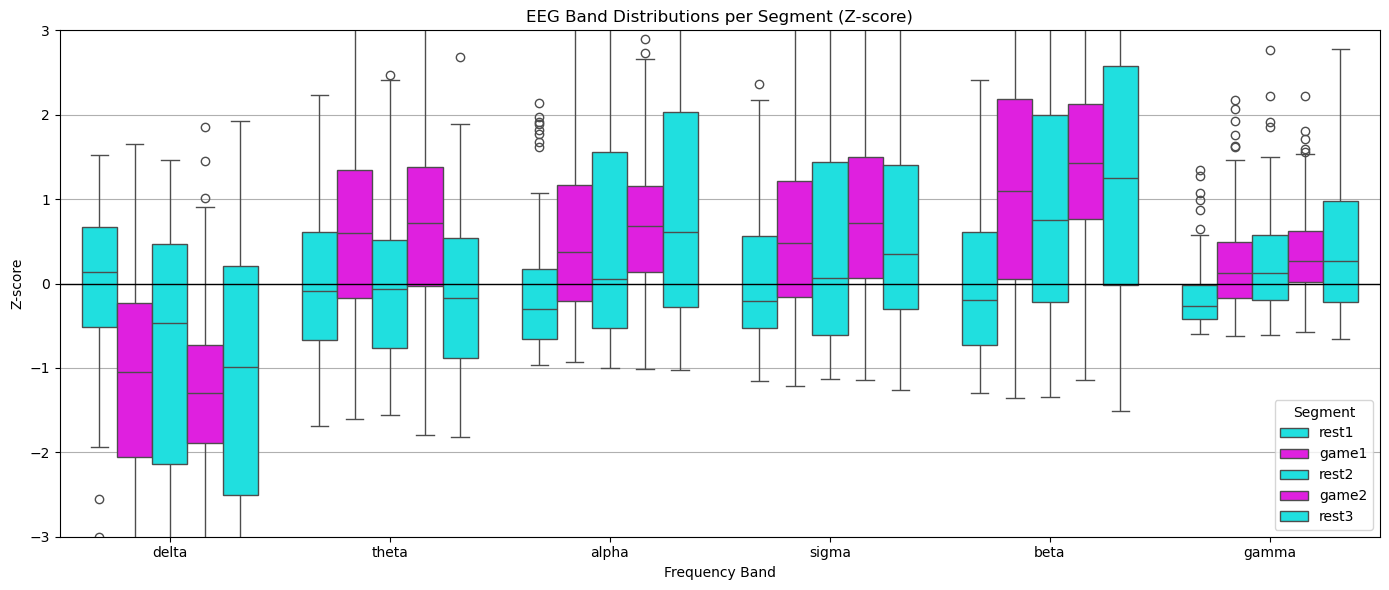

C:\Users\ruegg\AppData\Local\Temp\ipykernel_25224\900564588.py:66: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
C:\Users\ruegg\AppData\Local\Temp\ipykernel_25224\900564588.py:66: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
C:\Users\ruegg\AppData\Local\Temp\ipykernel_25224\900564588.py:66: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
C:\Users\ruegg\AppData\Local\Temp\ipykernel_25224\900564588.py:66: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable 

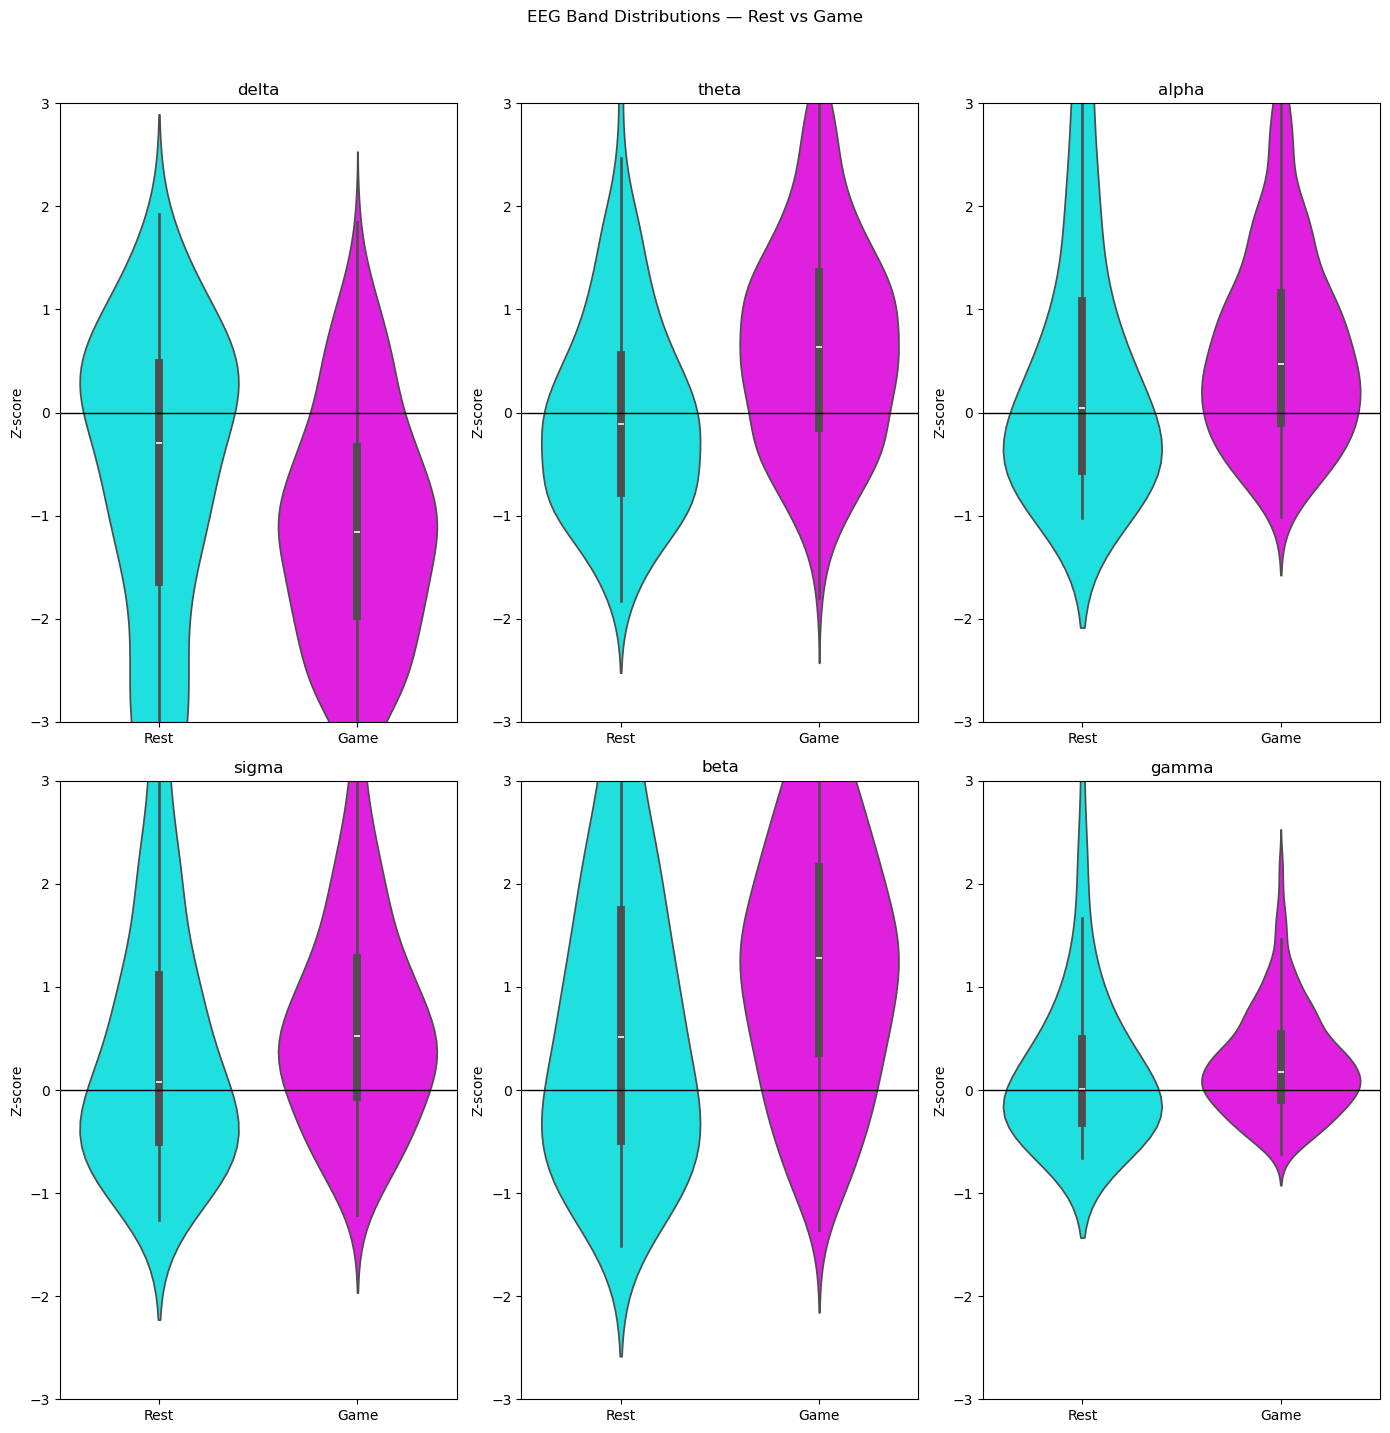

In [33]:



# ---------------------------------------------------
# ASSIGN SEGMENT LABELS
# ---------------------------------------------------
df["segment"] = "other"

for name, (start, end) in segments.items():
    mask = (df["time_sec"] >= start) & (df["time_sec"] < end)
    df.loc[mask, "segment"] = name

# ---------------------------------------------------
# MELT DATA (required for seaborn boxplot)
# ---------------------------------------------------
plot_df = df[df["segment"] != "other"].copy()

melted = plot_df.melt(
    id_vars=["segment"],
    value_vars=z_bands,
    var_name="band",
    value_name="zscore"
)

melted["band"] = melted["band"].str.replace("_z", "")

# ---------------------------------------------------
# BOX + WHISKER PLOT
# ---------------------------------------------------
plt.figure(figsize=(14, 6))

sns.boxplot(
    data=melted,
    x="band",
    y="zscore",
    hue="segment",
    palette=segment_colors
)

plt.axhline(0, color="black", linewidth=1)

plt.title("EEG Band Distributions per Segment (Z-score)")
plt.ylabel("Z-score")
plt.xlabel("Frequency Band")

plt.legend(title="Segment")
plt.grid(axis="y")
plt.ylim(-3, 3)
plt.tight_layout()

plt.show()

melted["segment_combined"] = melted["segment"].apply(
    lambda x: "Rest" if x in rests else ("Game" if x in games else "Other")
)

plot_df = melted[melted["segment_combined"] != "Other"]

# ---------------------------------------------------
# FIGURE: one subplot per band
# ---------------------------------------------------
fig, axes = plt.subplots(2, 3, figsize=(14, 14))
axes = axes.flatten()

palette = {"Rest": "cyan", "Game": "magenta"}

for i, b in enumerate(bandslist):

    sns.violinplot(
        data=plot_df[plot_df["band"] == b],
        x="segment_combined",
        y="zscore",
        palette=palette,
        ax=axes[i]
    )

    axes[i].axhline(0, color="black", linewidth=1)
    axes[i].set_title(f"{b}")
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Z-score")
    axes[i].set_ylim(-3, 3)

plt.suptitle("EEG Band Distributions — Rest vs Game", y=1.02)
plt.tight_layout()
plt.show()

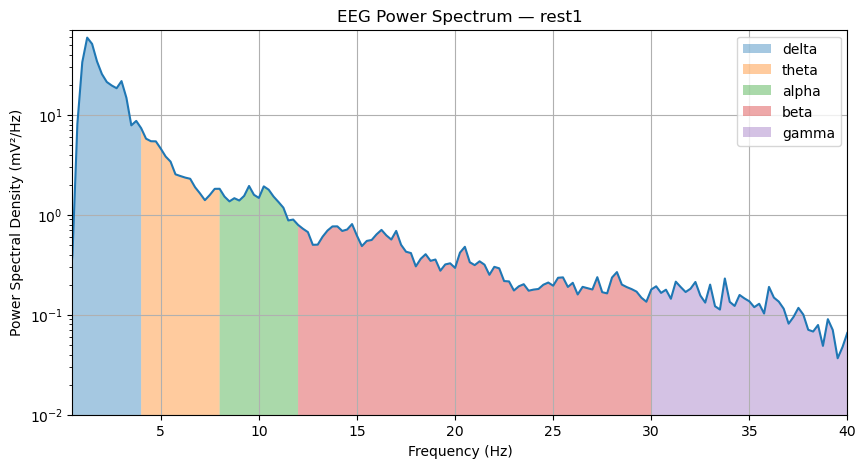

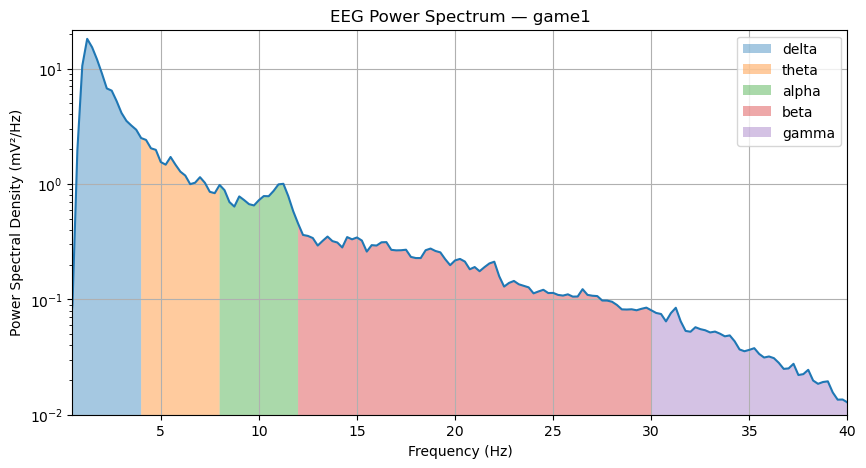

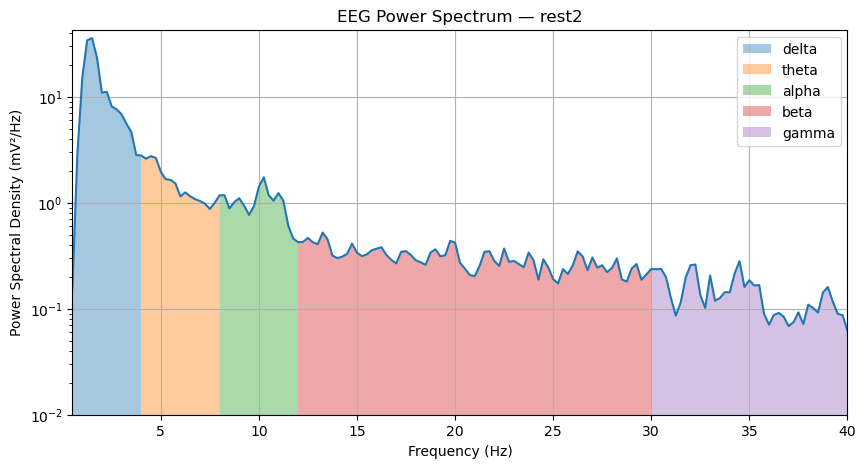

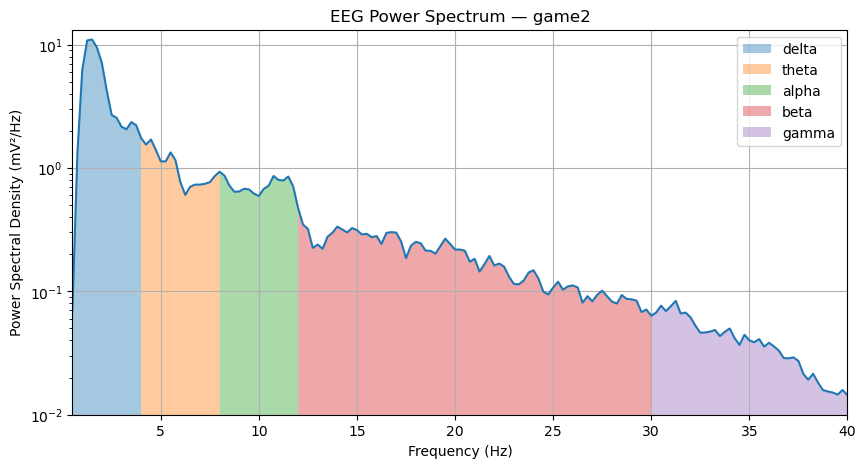

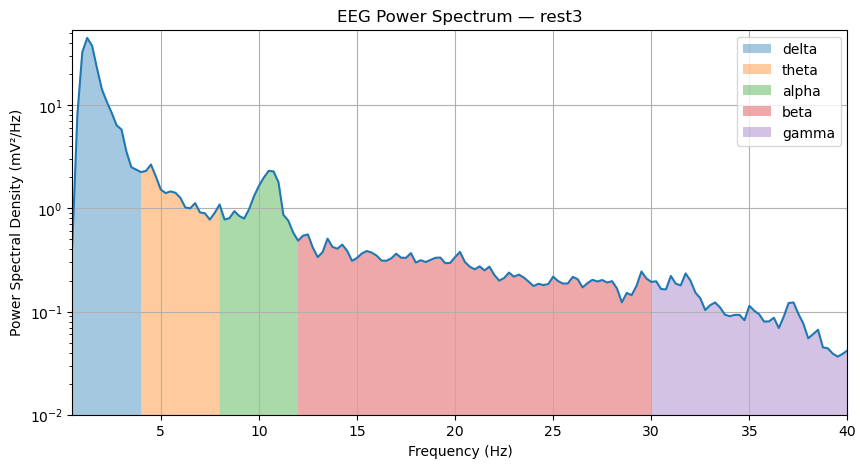

In [34]:
# ---------------------------------------------------
# LOOP THROUGH SEGMENTS
# ---------------------------------------------------
for name, (start, end) in segments.items():

    # convert time → indices
    seg = x_filt[int(start*fs):int(end*fs)]

    freqs, psd = welch(
        seg,
        fs=fs,
        nperseg=fs * 4,
        noverlap=fs * 2
    )

    plt.figure(figsize=(10, 5))

    plt.semilogy(freqs, psd)

    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Power Spectral Density (mV²/Hz)")
    plt.title(f"EEG Power Spectrum — {name}")

    plt.grid(True)

    plt.xlim([0.5, 40])

    # optional fixed visibility range (safe for EEG)
    plt.ylim([0.01, np.max(psd) * 1.2])

    # ---------------------------------------------------
    # FILL BAND AREAS
    # ---------------------------------------------------
    for band, (f_low, f_high) in bands.items():
        mask = (freqs >= f_low) & (freqs <= f_high)

        if np.any(mask):
            plt.fill_between(
                freqs[mask],
                psd[mask],
                alpha=0.4,
                label=band
            )

    plt.legend()
    plt.show()


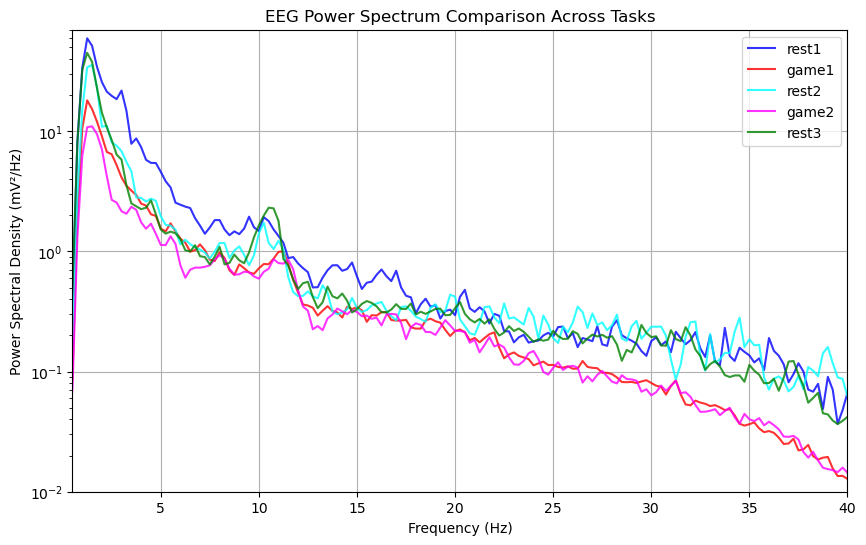

In [35]:
plt.figure(figsize=(10, 6))

for name, (start, end) in segments.items():

    seg = x_filt[int(start*fs):int(end*fs)]

    freqs, psd = welch(
        seg,
        fs=fs,
        nperseg=fs * 4,
        noverlap=fs * 2
    )

    plt.semilogy(freqs, psd, label=name, color=individual_colors[name], alpha=0.8)

# ---------------------------------------------------
# Styling
# ---------------------------------------------------
plt.xlabel("Frequency (Hz)")
plt.ylabel("Power Spectral Density (mV²/Hz)")
plt.title("EEG Power Spectrum Comparison Across Tasks")

plt.xlim(0.5, 40)
plt.ylim(0.01, 70)  # auto upper limit, fixed lower limit for visibility
plt.grid(True)
plt.legend()

plt.show()


EEG Band Power (% per segment):

       delta  theta  alpha   beta  gamma
rest1  75.63  11.74   5.32   6.11   1.21
game1  66.32  14.97   8.10   9.54   1.07
rest2  71.17  10.58   6.83   9.07   2.36
game2  59.99  15.35  10.64  12.50   1.52
rest3  75.20   8.35   7.26   7.56   1.63


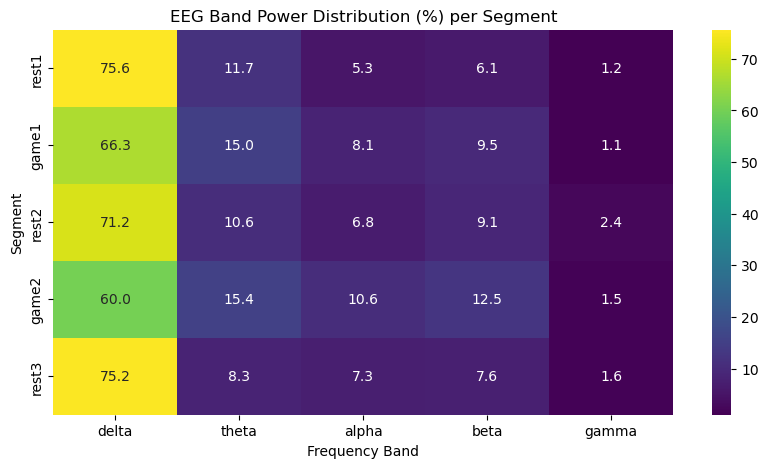

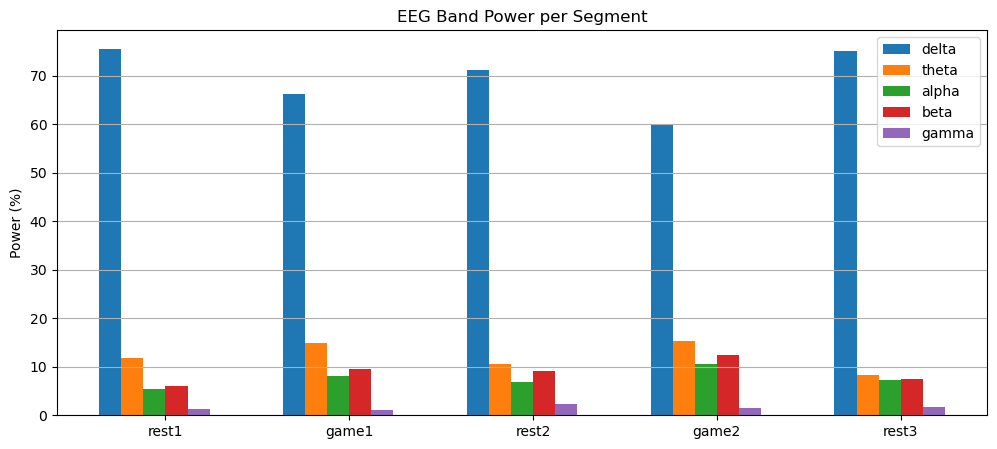

In [36]:
def band_power(freqs, psd, low, high):
    mask = (freqs >= low) & (freqs <= high)

    if np.sum(mask) == 0:
        return 0.0

    return trapezoid(psd[mask], freqs[mask])
results = {}

for name, (start, end) in segments.items():

    seg = x_filt[int(start*fs):int(end*fs)]

    freqs, psd = welch(
        seg,
        fs=fs,
        nperseg=fs * 4,
        noverlap=fs * 2
    )

    band_powers = {}

    for b, (low, high) in bands.items():
        band_powers[b] = band_power(freqs, psd, low, high)

    total_power = sum(band_powers.values()) + 1e-12

    band_percent = {b: (p / total_power) * 100 for b, p in band_powers.items()}

    results[name] = band_percent

# ---------------------------------------------------
# TABLE OUTPUT
# ---------------------------------------------------
df_percent = pd.DataFrame(results).T

print("\nEEG Band Power (% per segment):\n")
print(df_percent.round(2))

plt.figure(figsize=(10, 5))

sns.heatmap(
    df_percent,
    annot=True,
    cmap="viridis",
    fmt=".1f"
)

plt.title("EEG Band Power Distribution (%) per Segment")
plt.ylabel("Segment")
plt.xlabel("Frequency Band")
plt.show()

bands_names = df_percent.columns # these are the band names (delta, theta, etc)
segments_names = df_percent.index # these are the segment names (rest1, game1, etc)

x = np.arange(len(segments_names))
width = 0.12

plt.figure(figsize=(12, 5))

for i, b in enumerate(bands_names):
    plt.bar(
        x + i * width,
        df_percent[b],
        width=width,
        label=b
    )

plt.xticks(x + width * 2.5, segments_names)
plt.ylabel("Power (%)")
plt.title("EEG Band Power per Segment")
plt.legend()
plt.grid(axis="y")
plt.show()


EEG Band Activity (relative to mean):

       delta  theta  alpha   beta  gamma
rest1  0.900  0.850  0.399  0.377  0.421
game1 -0.420 -0.178 -0.258 -0.251 -0.563
rest2 -0.019 -0.085 -0.015  0.122  0.520
game2 -0.625 -0.397 -0.303 -0.298 -0.557
rest3  0.164 -0.189  0.177  0.050  0.178


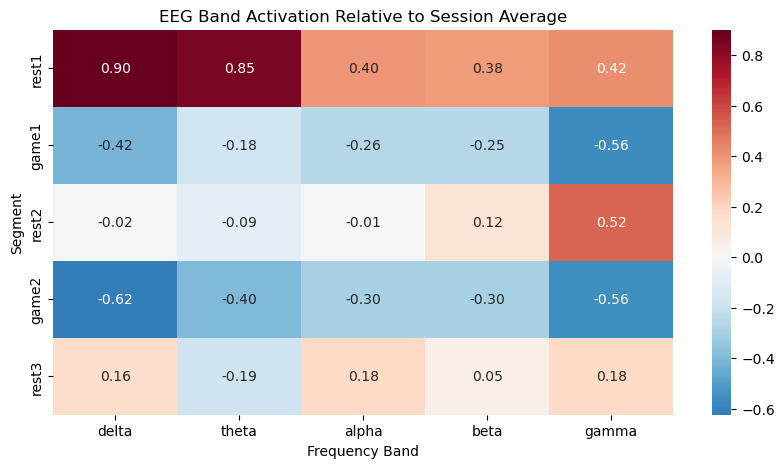

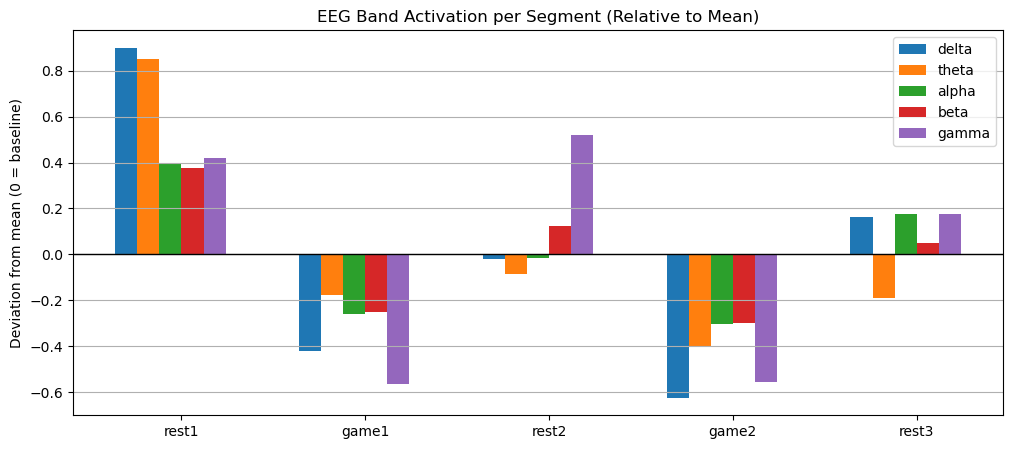

In [37]:
# ---------------------------------------------------
# FEATURE EXTRACTION PER SEGMENT
# ---------------------------------------------------
results_raw = {}

for name, (start, end) in segments.items():

    seg = x_filt[int(start*fs):int(end*fs)]

    freqs, psd = welch(
        seg,
        fs=fs,
        nperseg=fs * 4,
        noverlap=fs * 2
    )

    band_powers = {}

    for b, (low, high) in bands.items():
        band_powers[b] = band_power(freqs, psd, low, high)

    results_raw[name] = band_powers

# ---------------------------------------------------
# DATAFRAME
# ---------------------------------------------------
df_raw = pd.DataFrame(results_raw).T

# ---------------------------------------------------
# NORMALISATION (KEY PART)
# each band compared to its own mean across all segments
# ---------------------------------------------------
band_means = df_raw.mean()

df_norm = df_raw / band_means

# convert to "activation vs baseline"
df_norm = df_norm - 1.0

print("\nEEG Band Activity (relative to mean):\n")
print(df_norm.round(3))

# ---------------------------------------------------
# HEATMAP
# ---------------------------------------------------
plt.figure(figsize=(10, 5))

sns.heatmap(
    df_norm,
    annot=True,
    cmap="RdBu_r",
    center=0,
    fmt=".2f"
)

plt.title("EEG Band Activation Relative to Session Average")
plt.ylabel("Segment")
plt.xlabel("Frequency Band")
plt.show()

# ---------------------------------------------------
# BAR PLOT
# ---------------------------------------------------
bands_list = df_norm.columns
segments_list = df_norm.index

x = np.arange(len(segments_list))
width = 0.12

plt.figure(figsize=(12, 5))

for i, b in enumerate(bands_list):
    plt.bar(
        x + i * width,
        df_norm[b],
        width=width,
        label=b
    )

plt.axhline(0, color="black", linewidth=1)

plt.xticks(x + width * 2.5, segments_list)
plt.ylabel("Deviation from mean (0 = baseline)")
plt.title("EEG Band Activation per Segment (Relative to Mean)")
plt.legend()
plt.grid(axis="y")
plt.show()